In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [49]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm, TwoSlopeNorm
from shapely import wkt
from catboost import CatBoostRegressor
from catboost import CatBoostRanker, Pool
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
file_path = "/content/drive/MyDrive/Проект_итог/bryansk_feature.csv"
bryansk_feature = gpd.read_file(file_path)

In [5]:
file_path = "/content/drive/MyDrive/Проект_итог/bryansk_target.csv"
bryansk_target = gpd.read_file(file_path)

In [6]:
# Копируем исходные датасеты
features_gdf = bryansk_feature.copy()
target_df = bryansk_target.copy()

# Список spatial-признаков grid-клеток, которые будут использоваться в модели
feature_cols = [
    "municipality_area",
    "total_building_area",
    "number_of_buildings",
    "building_coverage",
    "road_length",
    "road_density",
    "nature_area",
    "nature_density",
    "ntl_mean",
    "ntl_sum",
    "ntl_max",
    "height_mean",
    "height_min",
    "height_max",
    "height_std",
    "height_range",
]

# Приводим признаки к числовому типу. Ошибки преобразования заменяем на NaN, затем заменяем на 0
for col in feature_cols:
    features_gdf[col] = pd.to_numeric(
        features_gdf[col],
        errors="coerce"
    ).fillna(0)

# Приводим население муниципалитета к numeric
target_df["total_population"] = pd.to_numeric(
    target_df["total_population"],
    errors="coerce"
)

# Очищаем названия муниципалитетов
features_gdf["municipality"] = (
    features_gdf["municipality"]
    .astype(str)
    .str.strip()
)

target_df["municipality"] = (
    target_df["municipality"]
    .astype(str)
    .str.strip()
)

# Удаляем возможные дубли municipality в aggregated target
target_df = target_df.drop_duplicates(
    subset=["municipality"]
)

# Объединяем grid-признаки с aggregated population target.
# После merge каждая клетка получает population своего municipality
grid = features_gdf.merge(
    target_df[["municipality", "total_population"]],
    on="municipality",
    how="left"
)

In [7]:
# Малое значение для защиты от деления на 0 log(0)
eps = 1e-9

# Определяем "пустые" клетки
grid["is_empty_cell"] = (
    (grid["total_building_area"] <= 0) &
    (grid["number_of_buildings"] <= 0) &
    (grid["road_length"] <= 0)
)

# Создаем proxy spatial score - эвристическую оценку "привлекательности" клетки для распределения населения
# log1p используется для уменьшения влияния экстремально больших значений
grid["proxy_score"] = (
    0.35 * np.log1p(grid["total_building_area"])
    + 0.25 * np.log1p(grid["number_of_buildings"])
    + 0.20 * np.log1p(grid["road_length"])
    + 0.20 * np.log1p(grid["ntl_mean"])
    - 0.30 * grid["nature_density"]
)

# Пустым клеткам задаем очень низкий score, чтобы минимизировать распределение населения в них
grid.loc[grid["is_empty_cell"], "proxy_score"] = -20

In [8]:
def group_softmax(x):
    """
   Функция softmax для преобразования spatial score
   в вероятностное распределение внутри municipality
    x - x.max() используется для численной стабильности,
   чтобы избежать переполнения exp()
   """
    x = x - x.max()
    exp_x = np.exp(x)
    return exp_x / exp_x.sum()

# Преобразуем proxy_score в доли населения.

# proxy_share показывает, какую долю населения municipality получает каждая grid-клетка
grid["proxy_share"] = (
    grid.groupby("municipality")["proxy_score"]
    .transform(group_softmax)
)

# Распределяем aggregated population по grid-клеткам пропорционально proxy_share

# proxy_population — synthetic population target для клетки
grid["proxy_population"] = (
    grid["proxy_share"] * grid["total_population"]
)

def group_softmax(x):
    """
   Функция softmax для преобразования spatial score
   в вероятностное распределение внутри municipality
    x - x.max() используется для численной стабильности,
   чтобы избежать переполнения exp()
   """
    x = x - x.max()
    exp_x = np.exp(x)
    return exp_x / exp_x.sum()

# Преобразуем proxy_score в доли населения.

# proxy_share показывает, какую долю населения municipality получает каждая grid-клетка
grid["proxy_share"] = (
    grid.groupby("municipality")["proxy_score"]
    .transform(group_softmax)
)

# Распределяем aggregated population по grid-клеткам пропорционально proxy_share

# proxy_population — synthetic population target для клетки
grid["proxy_population"] = (
    grid["proxy_share"] * grid["total_population"]
)

# Создаем log-target для обучения модели.
# Логарифм уменьшает скошенность распределения и стабилизирует обучение
grid["log_proxy_share"] = np.log(
    grid["proxy_share"] + eps
)

# Равномерное распределение внутри municipality — baseline
grid["uniform_share"] = (
    1 / grid.groupby("municipality")["grid_id"].transform("count")
)

grid["uniform_population"] = (
    grid["uniform_share"] * grid["total_population"]
)

# Смешиваем proxy-распределение с равномерным baseline
alpha = 0.85

grid["mixed_share"] = (
    alpha * grid["proxy_share"] +
    (1 - alpha) * grid["uniform_share"]
)

# На всякий случай нормализуем mixed_share внутри municipality
grid["mixed_share"] = (
    grid["mixed_share"] /
    grid.groupby("municipality")["mixed_share"].transform("sum")
)

grid["mixed_population"] = (
    grid["mixed_share"] * grid["total_population"]
)

# Создаем log-target для обучения модели.
# Логарифм уменьшает скошенность распределения и стабилизирует обучение
grid["log_proxy_share"] = np.log(
    grid["mixed_share"] + eps
)

In [9]:
# Создаем engineered features

# Логарифмируем базовые признаки
grid["log_building_area"] = np.log1p(
    grid["total_building_area"]
)

grid["log_number_of_buildings"] = np.log1p(
    grid["number_of_buildings"]
)

grid["log_road_length"] = np.log1p(
    grid["road_length"]
)

grid["log_nature_area"] = np.log1p(
    grid["nature_area"]
)

# Логарифмируем night-time lights признаки
grid["log_ntl_mean"] = np.log1p(
    grid["ntl_mean"]
)

grid["log_ntl_sum"] = np.log1p(
    grid["ntl_sum"]
)

grid["log_ntl_max"] = np.log1p(
    grid["ntl_max"]
)

# Interaction feature:
# совместный эффект застройки и дорожной сети
grid["built_road_interaction"] = (
    grid["building_coverage"] *
    grid["road_density"]
)

# Urban-light interaction:
# совместный эффект застройки и ночного освещения
grid["built_ntl_interaction"] = (
    grid["building_coverage"] *
    grid["ntl_mean"]
)

# Road-light interaction:
# совместный эффект дорог и ночного освещения
grid["road_ntl_interaction"] = (
    grid["road_density"] *
    grid["ntl_mean"]
)

# Отношение площади зданий к длине дорог
grid["building_per_road"] = (
    grid["total_building_area"] /
    (grid["road_length"] + eps)
)

# Доля застроенности относительно природных территорий
grid["urban_nature_ratio"] = (
    grid["building_coverage"] /
    (grid["nature_density"] + eps)
)

# Штраф за природные территории
grid["nature_penalty"] = (
    grid["nature_density"] *
    (1 - grid["building_coverage"])
)

# Roughness рельефа:
# общий показатель неровности территории
grid["terrain_roughness"] = (
    grid["height_std"] +
    grid["height_range"]
)

In [10]:
# Список признаков, на которых обучается RMSE-модель
model_features = [
    "municipality_area",
    "total_building_area",
    "number_of_buildings",
    "building_coverage",
    "road_length",
    "road_density",
    "nature_area",
    "nature_density",
    "ntl_mean",
    "ntl_sum",
    "ntl_max",
    "height_mean",
    "height_min",
    "height_max",
    "height_std",
    "height_range",
    "log_building_area",
    "log_number_of_buildings",
    "log_road_length",
    "log_nature_area",
    "log_ntl_mean",
    "log_ntl_sum",
    "log_ntl_max",
    "built_road_interaction",
    "built_ntl_interaction",
    "road_ntl_interaction",
    "building_per_road",
    "urban_nature_ratio",
    "nature_penalty",
    "terrain_roughness",
]

X = grid[model_features] # признаки grid-клеток
y = grid["log_proxy_share"] # proxy target в log-scale

# Делим данные на train и validation по municipality (клетки одного municipality не должны одновременно попасть и в train, и в validation)
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, valid_idx = next(
    splitter.split(
        X,
        y,
        groups=grid["municipality"]
    )
)

# Формируем train и validation выборки
X_train = X.iloc[train_idx]
X_valid = X.iloc[valid_idx]

y_train = y.iloc[train_idx]
y_valid = y.iloc[valid_idx]

# Обучаем CatBoostRegressor.
# Модель учится предсказывать log_proxy_share (логарифм доли населения клетки)
model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=10,
    random_seed=42,
    verbose=200
)

# Обучение модели с validation set (use_best_model=True оставляет лучшую итерацию)
model.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	learn: 1.0693184	test: 1.0588602	best: 1.0588602 (0)	total: 241ms	remaining: 4m
200:	learn: 0.3746519	test: 0.4694801	best: 0.4694801 (200)	total: 8.01s	remaining: 31.8s
400:	learn: 0.3567370	test: 0.4661696	best: 0.4661094 (381)	total: 16.5s	remaining: 24.6s
600:	learn: 0.3441010	test: 0.4650781	best: 0.4650752 (586)	total: 22.8s	remaining: 15.1s
800:	learn: 0.3338073	test: 0.4645388	best: 0.4644182 (749)	total: 31.3s	remaining: 7.77s
999:	learn: 0.3245475	test: 0.4645300	best: 0.4643032 (820)	total: 37.6s	remaining: 0us

bestTest = 0.46430317
bestIteration = 820

Shrink model to first 821 iterations.


CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=1000, l2_leaf_reg=10, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=200)

In [11]:
# Получаем предсказание модели (log-доля населения)
grid["pred_log_share_raw"] = model.predict(
    grid[model_features]
)

# Возвращаемся из log-scale обратно в обычный score
grid["pred_score"] = np.exp(
    grid["pred_log_share_raw"]
)

# Для пустых клеток принудительно задаем score = 0
grid.loc[
    grid["is_empty_cell"],
    "pred_score"
] = 0

# Считаем сумму predicted scores внутри каждого municipality
grid["municipality_pred_score_sum"] = (
    grid.groupby("municipality")["pred_score"]
    .transform("sum")
)

# Нормализуем predicted scores.
# Если сумма score равна 0, ставим pred_share = 0
grid["pred_share"] = np.where(
    grid["municipality_pred_score_sum"] > 0,
    grid["pred_score"] / grid["municipality_pred_score_sum"],
    0
)

# Распределяем население municipality по клеткам согласно pred_share
grid["pred_population"] = (
    grid["pred_share"] *
    grid["total_population"]
)

In [12]:
# Берем только validation часть данных
valid_grid = grid.iloc[valid_idx].copy()

# Считаем MSE (сравнение идет в log-space)
mse_log_share = mean_squared_error(
    valid_grid["log_proxy_share"],
    valid_grid["pred_log_share_raw"]
)

# Преобразуем MSE в RMSE
rmse_log_share = np.sqrt(
    mse_log_share
)

# Средняя абсолютная ошибка в долях населения
mae_share = mean_absolute_error(
    valid_grid["proxy_share"],
    valid_grid["pred_share"]
)

# R² в log-space
r2_log_share = r2_score(
    valid_grid["log_proxy_share"],
    valid_grid["pred_log_share_raw"]
)

# Корреляция между proxy_share и pred_share
corr_share = valid_grid[
    ["proxy_share", "pred_share"]
].corr().iloc[0, 1]

# Проверяем conservation:
# сумма pred_share внутри municipality должна быть близка к 1
municipality_share_check = (
    valid_grid.groupby("municipality")["pred_share"]
    .sum()
)

mean_share_sum = municipality_share_check.mean()

# Выводим основные метрики качества модели
print("RMSE log-share:", rmse_log_share)
print("MAE share:", mae_share)
print("R2 log-share:", r2_log_share)
print("Correlation share:", corr_share)
print("Mean municipality share sum:", mean_share_sum)

RMSE log-share: 0.4643031529793327
MAE share: 0.00030242523843379576
R2 log-share: 0.8010760362775808
Correlation share: 0.9742799902995427
Mean municipality share sum: 1.0


In [13]:
# Формируем итоговый GeoDataFrame

result_gdf = grid[
    [
        "grid_id",
        "municipality",
        "total_population",
        "proxy_score",
        "proxy_share",
        "proxy_population",
        "uniform_share",
        "uniform_population",
        "mixed_share",
        "mixed_population",
        "pred_score",
        "pred_share",
        "pred_population",
        "is_empty_cell",
        "geometry"
    ]
].copy()

In [14]:
# Сохраняем итоговый GeoDataFrame как bryansk_population_grid_1km_regression.gpkg

result_gdf = result_gdf.copy()

# Преобразуем geometry из WKT в shapely geometry
result_gdf["geometry"] = result_gdf["geometry"].apply(
    lambda geom: wkt.loads(geom)
    if isinstance(geom, str)
    else geom
)

# Создаем GeoDataFrame
result_gdf = gpd.GeoDataFrame(
    result_gdf,
    geometry="geometry",
    crs="EPSG:4326"
)

# Сохраняем результат
result_gdf.to_file(
    "/content/drive/MyDrive/Проект_итог/bryansk_population_grid_1km_regression.gpkg",
    layer="population_grid",
    driver="GPKG"
)

In [15]:
# Создаем отдельную таблицу для ranking-модели
rank_grid = grid.copy()

eps = 1e-9

# Создаем ranking target — relevance.
# Переводим proxy_share в относительную "важность" клетки.
# Чем выше relevance, тем выше приоритет клетки внутри municipality.
rank_grid["relevance"] = np.log1p(
    rank_grid["proxy_share"] /
    (rank_grid["proxy_share"].mean() + eps)
)

# Пустым клеткам задаем минимальную relevance
rank_grid.loc[
    rank_grid["is_empty_cell"],
    "relevance"
] = 0

In [16]:
# Используем тот же набор spatial-признаков, что и для regression RMSE-модели
rank_features = [
    "municipality_area",
    "total_building_area",
    "number_of_buildings",
    "building_coverage",
    "road_length",
    "road_density",
    "nature_area",
    "nature_density",
    "ntl_mean",
    "ntl_sum",
    "ntl_max",
    "height_mean",
    "height_min",
    "height_max",
    "height_std",
    "height_range",
    "log_building_area",
    "log_number_of_buildings",
    "log_road_length",
    "log_nature_area",
    "log_ntl_mean",
    "log_ntl_sum",
    "log_ntl_max",
    "built_road_interaction",
    "built_ntl_interaction",
    "road_ntl_interaction",
    "building_per_road",
    "urban_nature_ratio",
    "nature_penalty",
    "terrain_roughness",
]

X = rank_grid[rank_features]
y = rank_grid["relevance"]
groups = rank_grid["municipality"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, valid_idx = next(
    splitter.split(
        X,
        y,
        groups=groups
    )
)

train_df = rank_grid.iloc[train_idx].copy()
valid_df = rank_grid.iloc[valid_idx].copy()

# Для CatBoostRanker объекты одной группы должны идти подряд, поэтому сортируем данные по municipality
train_df = (
    train_df
    .sort_values("municipality")
    .reset_index(drop=True)
)

valid_df = (
    valid_df
    .sort_values("municipality")
    .reset_index(drop=True)
)

# Создаем CatBoost Pool для train-выборки.
# Pool — формат данных CatBoost, который хранит признаки, target, group_id для ranking-задач
train_pool = Pool(
    data=train_df[rank_features],
    label=train_df["relevance"],
    group_id=train_df["municipality"]
)

valid_pool = Pool(
    data=valid_df[rank_features],
    label=valid_df["relevance"],
    group_id=valid_df["municipality"]
)

In [17]:
# Создаем CatBoost ranking-модель.
# Ranking model учится не точным значениям долей, а относительной важности клеток
ranker = CatBoostRanker(
    loss_function="YetiRank",
    eval_metric="NDCG:top=20",
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=10,
    random_seed=42,
    verbose=200
)

# Обучаем ranking-модель
ranker.fit(
    train_pool,
    eval_set=valid_pool,
    use_best_model=True
)

0:	test: 0.6649716	best: 0.6649716 (0)	total: 453ms	remaining: 7m 32s
200:	test: 0.9304043	best: 0.9304043 (200)	total: 1m 46s	remaining: 7m 4s
400:	test: 0.9556771	best: 0.9556993 (398)	total: 3m 35s	remaining: 5m 21s
600:	test: 0.9722863	best: 0.9722913 (598)	total: 5m 34s	remaining: 3m 42s
800:	test: 0.9791875	best: 0.9791875 (789)	total: 7m 24s	remaining: 1m 50s
999:	test: 0.9825924	best: 0.9825924 (992)	total: 9m 14s	remaining: 0us

bestTest = 0.9825924212
bestIteration = 992

Shrink model to first 993 iterations.


CatBoostRanker(depth=8, eval_metric='NDCG:top=20', iterations=1000, l2_leaf_reg=10, learning_rate=0.03, loss_function='YetiRank', random_seed=42, verbose=200)

In [18]:
# Получаем raw ranking score для каждой клетки (модельная оценка относительной важности клетки)
rank_grid["rank_score_raw"] = ranker.predict(
    rank_grid[rank_features]
)

# Пустым клеткам задаем очень низкий ranking score
rank_grid.loc[
    rank_grid["is_empty_cell"],
    "rank_score_raw"
] = -20

# Получаем долю населения клетки
rank_grid["rank_share"] = (
    rank_grid.groupby("municipality")["rank_score_raw"]
    .transform(group_softmax)
)

# Распределяем total_population municipality по клеткам согласно rank_share
rank_grid["rank_population"] = (
    rank_grid["rank_share"] *
    rank_grid["total_population"]
)

In [24]:
# Метрики ranking-модели

# Берем только validation часть данных
valid_rank_grid = rank_grid.iloc[valid_idx].copy()

# MSE между proxy_share и rank_share
rank_mse_share = mean_squared_error(
    valid_rank_grid["proxy_share"],
    valid_rank_grid["rank_share"]
)

# RMSE
rank_rmse_share = np.sqrt(
    rank_mse_share
)

# MAE
rank_mae_share = mean_absolute_error(
    valid_rank_grid["proxy_share"],
    valid_rank_grid["rank_share"]
)

# R2
rank_r2_share = r2_score(
    valid_rank_grid["proxy_share"],
    valid_rank_grid["rank_share"]
)

# Корреляция
rank_corr_share = valid_rank_grid[
    ["proxy_share", "rank_share"]
].corr().iloc[0, 1]

# Проверяем conservation:
# сумма rank_share внутри municipality должна быть 1
rank_municipality_share_check = (
    valid_rank_grid.groupby("municipality")["rank_share"]
    .sum()
)

rank_mean_share_sum = (
    rank_municipality_share_check.mean()
)

# Выводим основные метрики качества ranking-модели
print("Ranking RMSE share:", rank_rmse_share)
print("Ranking MAE share:", rank_mae_share)
print("Ranking R2 share:", rank_r2_share)
print("Ranking Correlation share:", rank_corr_share)
print("Ranking Mean municipality share sum:", rank_mean_share_sum)

Ranking RMSE share: 0.0027728583330816504
Ranking MAE share: 0.0005360630723668388
Ranking R2 share: 0.6924830125513914
Ranking Correlation share: 0.9235314287560905
Ranking Mean municipality share sum: 1.0


In [19]:
# Сохраняем итоговый GeoDataFrame как bryansk_population_grid_1km_ranking.gpkg

rank_result_gdf = rank_grid.copy()

# Преобразуем geometry из WKT в shapely geometry
rank_result_gdf["geometry"] = rank_result_gdf["geometry"].apply(
    lambda geom: wkt.loads(geom)
    if isinstance(geom, str)
    else geom
)

# Создаем GeoDataFrame и задаем CRS
rank_result_gdf = gpd.GeoDataFrame(
    rank_result_gdf,
    geometry="geometry",
    crs="EPSG:4326"
)

# Сохраняем результат в Google Drive
rank_result_gdf.to_file(
    "/content/drive/MyDrive/Проект_итог/bryansk_population_grid_1km_ranking.gpkg",
    layer="population_grid_ranking",
    driver="GPKG"
)

In [20]:
# Пути для сохранения моделей
regression_model_path = "/content/drive/MyDrive/Проект_итог/catboost_regression_population_model.cbm"
ranking_model_path = "/content/drive/MyDrive/Проект_итог/catboost_ranking_population_model.cbm"

# Сохраняем regression-модель
model.save_model(regression_model_path)

# Сохраняем ranking-модель
ranker.save_model(ranking_model_path)

/tmp/ipykernel_13978/1170268183.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("turbo").copy()


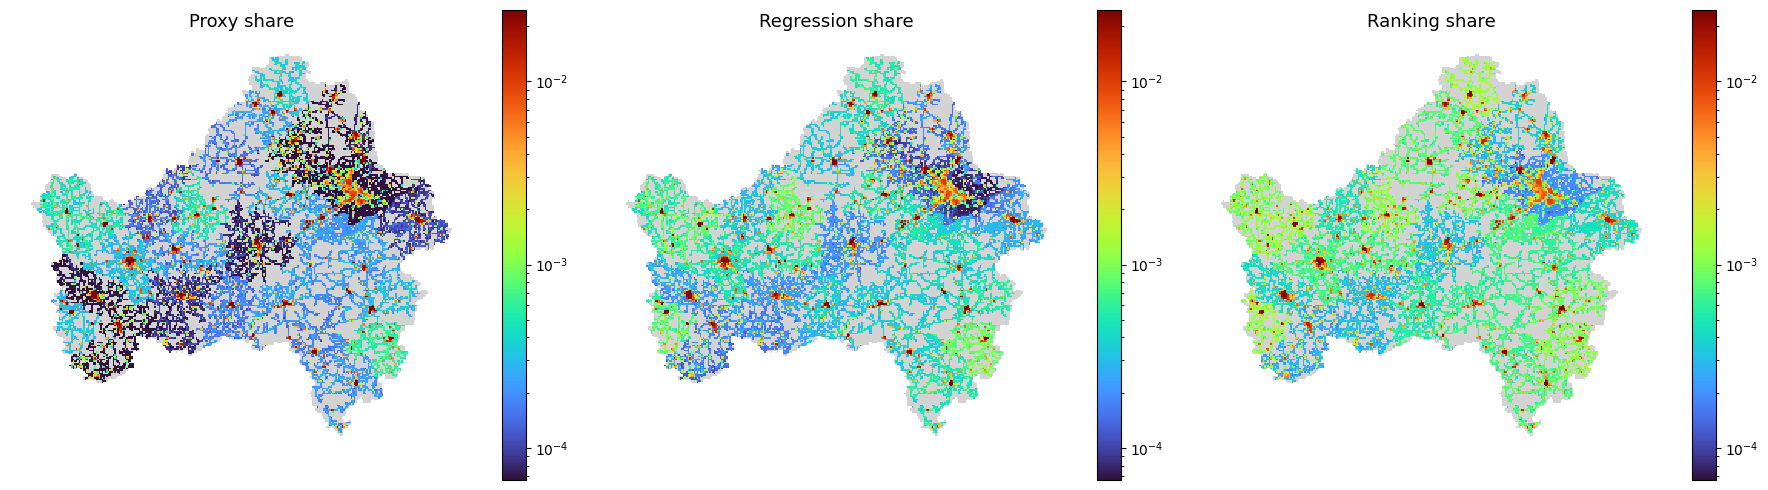

/tmp/ipykernel_13978/1170268183.py:125: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_diff = cm.get_cmap("coolwarm").copy()


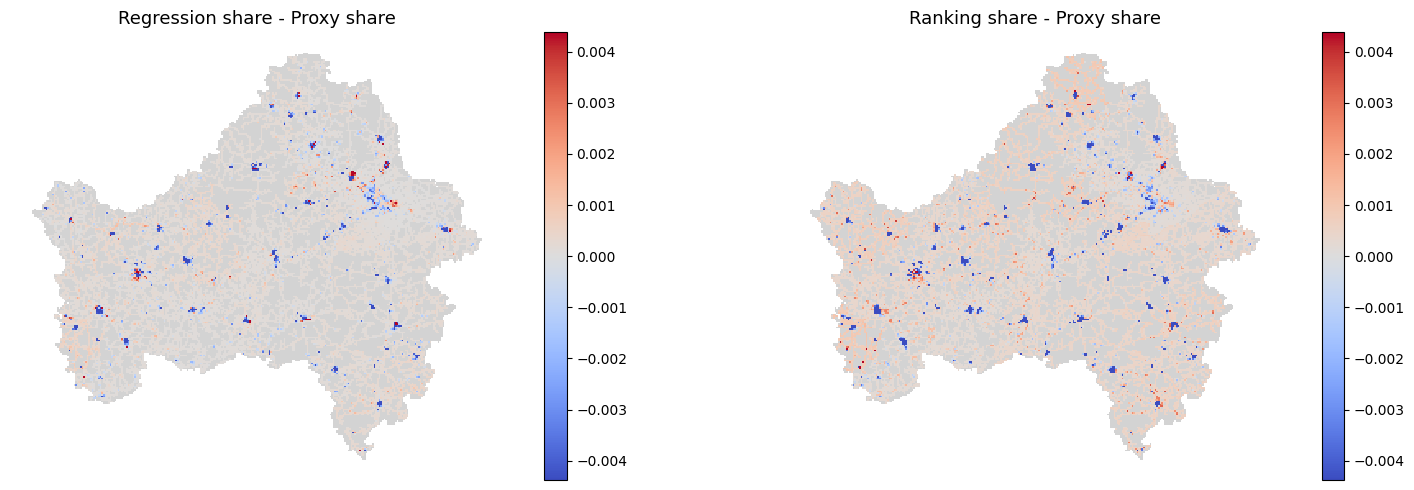

In [23]:
# Визуализация

# Добавляем ranking-результаты в result_gdf
if "rank_share" not in result_gdf.columns:
    rank_result = rank_grid[
        [
            "grid_id",
            "rank_share",
            "rank_population"
        ]
    ].copy()

    result_gdf = result_gdf.merge(
        rank_result,
        on="grid_id",
        how="left"
    )


# Карты: proxy, regression, ranking
share_cols = [
    ("proxy_share", "Proxy share"),
    ("pred_share", "Regression share"),
    ("rank_share", "Ranking share")
]

for col, title in share_cols:
    vis_col = col + "_vis"
    result_gdf[vis_col] = result_gdf[col].copy()

    result_gdf.loc[
        result_gdf["is_empty_cell"],
        vis_col
    ] = np.nan

positive_values = []

for col, title in share_cols:
    vis_col = col + "_vis"
    positive_values.extend(
        result_gdf.loc[result_gdf[vis_col] > 0, vis_col].values
    )

positive_values = np.array(positive_values)

vmin = np.percentile(positive_values, 5)
vmax = np.percentile(positive_values, 99)

cmap = cm.get_cmap("turbo").copy()
cmap.set_bad("lightgrey")

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5)
)

for ax, (col, title) in zip(axes, share_cols):
    result_gdf.plot(
        column=col + "_vis",
        cmap=cmap,
        legend=True,
        norm=LogNorm(vmin=vmin, vmax=vmax),
        ax=ax,
        missing_kwds={
            "color": "lightgrey",
            "label": "Empty cell"
        },
        edgecolor="none"
    )

    ax.set_title(title, fontsize=13)
    ax.axis("off")

plt.tight_layout()
plt.show()


# Карты разницы: models - proxy
result_gdf["reg_diff_vs_proxy"] = (
    result_gdf["pred_share"] -
    result_gdf["proxy_share"]
)

result_gdf["rank_diff_vs_proxy"] = (
    result_gdf["rank_share"] -
    result_gdf["proxy_share"]
)

result_gdf.loc[
    result_gdf["is_empty_cell"],
    ["reg_diff_vs_proxy", "rank_diff_vs_proxy"]
] = np.nan

diff_cols = [
    ("reg_diff_vs_proxy", "Regression share - Proxy share"),
    ("rank_diff_vs_proxy", "Ranking share - Proxy share")
]

# Берем перцентили, чтобы карта разности была контрастной
diff_values = []

for col, title in diff_cols:
    diff_values.extend(
        result_gdf[col].dropna().values
    )

diff_values = np.array(diff_values)

diff_limit = np.percentile(
    np.abs(diff_values),
    98
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 5)
)

cmap_diff = cm.get_cmap("coolwarm").copy()
cmap_diff.set_bad("lightgrey")

for ax, (col, title) in zip(axes, diff_cols):
    result_gdf.plot(
        column=col,
        cmap=cmap_diff,
        legend=True,
        norm=TwoSlopeNorm(
            vmin=-diff_limit,
            vcenter=0,
            vmax=diff_limit
        ),
        ax=ax,
        missing_kwds={
            "color": "lightgrey",
            "label": "Empty cell"
        },
        edgecolor="none"
    )

    ax.set_title(title, fontsize=13)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [27]:
# Итоговая гибридная модель
# Hybrid model: regression + ranking

# beta ближе к 1 = больше доверяем regression
# beta ближе к 0 = больше доверяем ranking
beta = 0.7

grid["hybrid_share"] = (
    beta * grid["pred_share"] +
    (1 - beta) * rank_grid["rank_share"]
)

# Нормализуем внутри каждого municipality,
# чтобы сумма долей была равна 1
grid["hybrid_share"] = (
    grid["hybrid_share"] /
    grid.groupby("municipality")["hybrid_share"].transform("sum")
)

# Распределяем население municipality по hybrid_share
grid["hybrid_population"] = (
    grid["hybrid_share"] *
    grid["total_population"]
)

# Проверка conservation
hybrid_check = (
    grid.groupby("municipality")["hybrid_share"]
    .sum()
)
# hybrid_check

/tmp/ipykernel_13978/2670360240.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("turbo").copy()


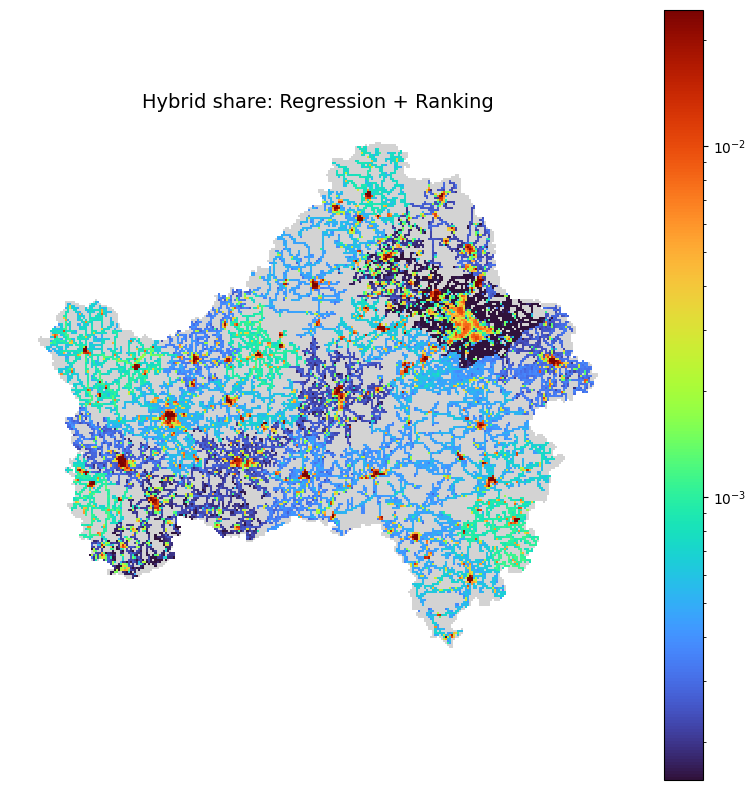

In [36]:
# Добавляем hybrid-результаты в result_gdf
if "hybrid_share" not in result_gdf.columns:
    hybrid_result = grid[
        [
            "grid_id",
            "hybrid_share",
            "hybrid_population"
        ]
    ].copy()

    result_gdf = result_gdf.merge(
        hybrid_result,
        on="grid_id",
        how="left"
    )

# Карта hybrid-модели
result_gdf["hybrid_share_vis"] = result_gdf["hybrid_share"].copy()

result_gdf.loc[
    result_gdf["is_empty_cell"],
    "hybrid_share_vis"
] = np.nan

positive_values = result_gdf.loc[
    result_gdf["hybrid_share_vis"] > 0,
    "hybrid_share_vis"
].values

vmin = np.percentile(positive_values, 5)
vmax = np.percentile(positive_values, 99)

cmap = cm.get_cmap("turbo").copy()
cmap.set_bad("lightgrey")

fig, ax = plt.subplots(
    figsize=(8, 8)
)

result_gdf.plot(
    column="hybrid_share_vis",
    cmap=cmap,
    legend=True,
    norm=LogNorm(vmin=vmin, vmax=vmax),
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "Empty cell"
    },
    edgecolor="none"
)

ax.set_title(
    "Hybrid share: Regression + Ranking",
    fontsize=14
)

ax.axis("off")

plt.tight_layout()
plt.show()

In [41]:
# Проверка на Курской области
file_path = "/content/drive/MyDrive/Проект_итог/grid_1km_Курск_v11.gpkg"
koorsk_feature = gpd.read_file(file_path)

Remaining cells: 30683
Municipalities: 32


/tmp/ipykernel_13978/2983391708.py:265: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("turbo").copy()


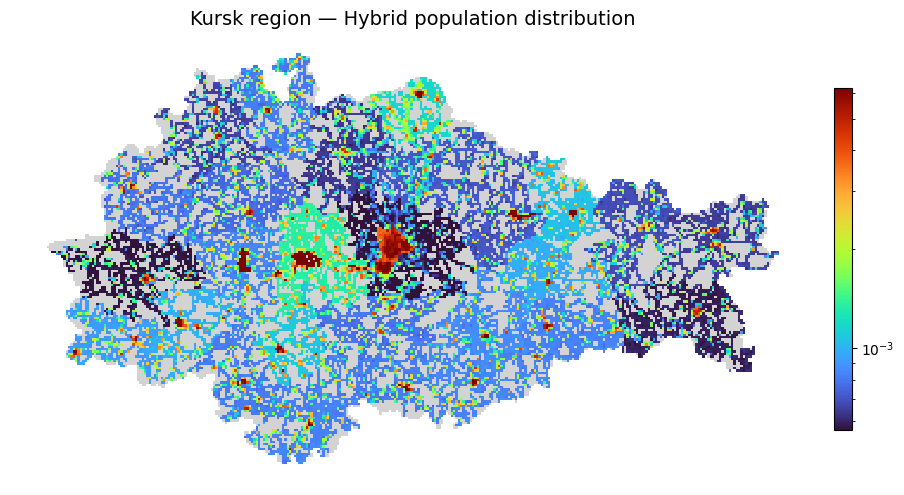

In [55]:
# Копируем исходный GeoDataFrame
kursk_grid = koorsk_feature.copy()

# Удаляем клетки без municipality
kursk_grid = kursk_grid[
    kursk_grid["municipality"].notna()
].copy()

# Чистим названия municipality
kursk_grid["municipality"] = (
    kursk_grid["municipality"]
    .astype(str)
    .str.strip()
)

# Удаляем пустые строки municipality
kursk_grid = kursk_grid[
    kursk_grid["municipality"] != ""
].copy()

# Сбрасываем индекс
kursk_grid = kursk_grid.reset_index(drop=True)

print("Remaining cells:", len(kursk_grid))
print(
    "Municipalities:",
    kursk_grid["municipality"].nunique()
)

# Оставляем только нужные фичи
required_cols = [
    "grid_id",
    "municipality",
    "municipality_area",
    "total_building_area",
    "number_of_buildings",
    "building_coverage",
    "road_length",
    "road_density",
    "nature_area",
    "nature_density",
    "ntl_mean",
    "ntl_sum",
    "ntl_max",
    "height_mean",
    "height_min",
    "height_max",
    "height_std",
    "height_range",
    "total_population",
    "geometry"
]

kursk_grid = kursk_grid[required_cols].copy()

# Приводим признаки к numeric
feature_cols = [
    "municipality_area",
    "total_building_area",
    "number_of_buildings",
    "building_coverage",
    "road_length",
    "road_density",
    "nature_area",
    "nature_density",
    "ntl_mean",
    "ntl_sum",
    "ntl_max",
    "height_mean",
    "height_min",
    "height_max",
    "height_std",
    "height_range",
]

for col in feature_cols:
    kursk_grid[col] = pd.to_numeric(
        kursk_grid[col],
        errors="coerce"
    ).fillna(0)

# Определяем "пустые" клетки
kursk_grid["is_empty_cell"] = (
    (kursk_grid["total_building_area"] <= 0) &
    (kursk_grid["number_of_buildings"] <= 0) &
    (kursk_grid["road_length"] <= 0)
)


# Engineered features
eps = 1e-9

kursk_grid["log_building_area"] = np.log1p(
    kursk_grid["total_building_area"]
)

kursk_grid["log_number_of_buildings"] = np.log1p(
    kursk_grid["number_of_buildings"]
)

kursk_grid["log_road_length"] = np.log1p(
    kursk_grid["road_length"]
)

kursk_grid["log_nature_area"] = np.log1p(
    kursk_grid["nature_area"]
)

kursk_grid["log_ntl_mean"] = np.log1p(
    kursk_grid["ntl_mean"]
)

kursk_grid["log_ntl_sum"] = np.log1p(
    kursk_grid["ntl_sum"]
)

kursk_grid["log_ntl_max"] = np.log1p(
    kursk_grid["ntl_max"]
)

kursk_grid["built_road_interaction"] = (
    kursk_grid["building_coverage"] *
    kursk_grid["road_density"]
)

kursk_grid["built_ntl_interaction"] = (
    kursk_grid["building_coverage"] *
    kursk_grid["ntl_mean"]
)

kursk_grid["road_ntl_interaction"] = (
    kursk_grid["road_density"] *
    kursk_grid["ntl_mean"]
)

kursk_grid["building_per_road"] = (
    kursk_grid["total_building_area"] /
    (kursk_grid["road_length"] + eps)
)

kursk_grid["urban_nature_ratio"] = (
    kursk_grid["building_coverage"] /
    (kursk_grid["nature_density"] + eps)
)

kursk_grid["nature_penalty"] = (
    kursk_grid["nature_density"] *
    (1 - kursk_grid["building_coverage"])
)

kursk_grid["terrain_roughness"] = (
    kursk_grid["height_std"] +
    kursk_grid["height_range"]
)

# Признаки модели
model_features = [
    "municipality_area",
    "total_building_area",
    "number_of_buildings",
    "building_coverage",
    "road_length",
    "road_density",
    "nature_area",
    "nature_density",
    "ntl_mean",
    "ntl_sum",
    "ntl_max",
    "height_mean",
    "height_min",
    "height_max",
    "height_std",
    "height_range",
    "log_building_area",
    "log_number_of_buildings",
    "log_road_length",
    "log_nature_area",
    "log_ntl_mean",
    "log_ntl_sum",
    "log_ntl_max",
    "built_road_interaction",
    "built_ntl_interaction",
    "road_ntl_interaction",
    "building_per_road",
    "urban_nature_ratio",
    "nature_penalty",
    "terrain_roughness",
]

# Regression prediction
kursk_grid["pred_log_share_raw"] = model.predict(
    kursk_grid[model_features]
)

kursk_grid["pred_score"] = np.exp(
    kursk_grid["pred_log_share_raw"]
)

kursk_grid.loc[
    kursk_grid["is_empty_cell"],
    "pred_score"
] = 0


# Ranking prediction
kursk_grid["rank_score_raw"] = ranker.predict(
    kursk_grid[model_features]
)

kursk_grid.loc[
    kursk_grid["is_empty_cell"],
    "rank_score_raw"
] = -20

kursk_grid["pred_share"] = (
    kursk_grid.groupby("municipality")["pred_score"]
    .transform(group_softmax)
)

kursk_grid["rank_share"] = (
    kursk_grid.groupby("municipality")["rank_score_raw"]
    .transform(group_softmax)
)


# Hybrid model
beta = 0.7

kursk_grid["hybrid_share"] = (
    beta * kursk_grid["pred_share"] +
    (1 - beta) * kursk_grid["rank_share"]
)

kursk_grid["hybrid_share"] = (
    kursk_grid["hybrid_share"] /
    kursk_grid.groupby("municipality")["hybrid_share"]
    .transform("sum")
)

kursk_grid["hybrid_population"] = (
    kursk_grid["hybrid_share"] *
    kursk_grid["total_population"]
)


# Визуализация
# Подготовка карты
kursk_grid["hybrid_share_vis"] = (
    kursk_grid["hybrid_share"]
)

kursk_grid.loc[
    kursk_grid["is_empty_cell"],
    "hybrid_share_vis"
] = np.nan

positive_values = kursk_grid.loc[
    kursk_grid["hybrid_share_vis"] > 0,
    "hybrid_share_vis"
].values

vmin = np.percentile(positive_values, 5)
vmax = np.percentile(positive_values, 99)

cmap = cm.get_cmap("turbo").copy()
cmap.set_bad("lightgrey")

# Карта
fig, ax = plt.subplots(
    figsize=(10, 6)
)

kursk_grid.plot(
    column="hybrid_share_vis",
    cmap=cmap,
    legend=True,
    norm=LogNorm(vmin=vmin, vmax=vmax),
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "Empty cell"
    },
    legend_kwds={
        "shrink": 0.6,
        "pad": 0.02
    }
)

ax.set_title(
    "Kursk region — Hybrid population distribution",
    fontsize=14
)

ax.axis("off")

plt.tight_layout()
plt.show()